In [14]:
import numpy as np
N=40
opt = 'milp_cl'
n_workers = 20
milp_info_compressed = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt,N, 0), allow_pickle=True).item()['milp_info_compressed']
for job_idx in range(1,n_workers):
    tmp_vector = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt, N, job_idx), allow_pickle=True).item()['milp_info_compressed']
    milp_info_compressed = np.concatenate((milp_info_compressed, tmp_vector))
milp_info_compressed = milp_info_compressed[:120000, :]
np.save('data_optimal//data_%s_N%.2d_condensed.npy' %(opt,N), milp_info_compressed, allow_pickle=True)

In [5]:
import numpy as np
N = 40
opt = 'milp_cl'
milp_info_compressed = np.load('data_optimal//data_%s_N%.2d_condensed.npy' %(opt,N), allow_pickle=True)
milp_info_compressed.shape

(120000, 5593)

In [10]:
from rail_data_preprocess_original import get_preprocessed_data

threshold_counts = 25

output_get_preprocessed_data = get_preprocessed_data(opt, threshold_counts, N)

# N = output_get_preprocessed_data[0]
N_control = output_get_preprocessed_data[1]
# stacked_states_train=output_get_preprocessed_data[2]
# stacked_states_val=output_get_preprocessed_data[3]
stacked_actions_reduced_train=output_get_preprocessed_data[4]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
list_masks=output_get_preprocessed_data[6]
stacked_states_train_tensor=output_get_preprocessed_data[7]
stacked_states_val_tensor=output_get_preprocessed_data[8]
# state_min_reduced=output_get_preprocessed_data[9]
# state_max_reduced=output_get_preprocessed_data[10]
input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]

num_actions = total_action_set.shape[0]
seq_len=N_control

num_actions = 256
number of training points (before reduction): 96000
number of validation points (before reduction): 24000
number of training points (after reduction): 89112
number of validation points (after reduction): 22337
cntr_outlier_train: 6888	 cntr_outlier_val: 1663
data-processing finished


In [11]:
stacked_states_train_tensor.shape

torch.Size([89112, 1, 4002])

In [59]:
state_n.shape

(3, 38)

377


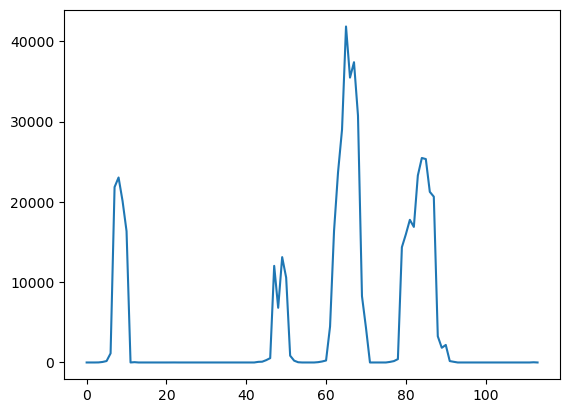

In [147]:
from rail_data_preprocess_original import decompress_minlp_info

i = np.random.randint(4000)

state_n, state_rho, state_depot, state_l, delta_minlp, obj_val, mipgap, runtime, status = decompress_minlp_info(milp_info_compressed[i,:], N-2)

print(i)

tmp = state_n.flatten()
# tmp = tmp[tmp<100]

plt.plot(tmp[0:])

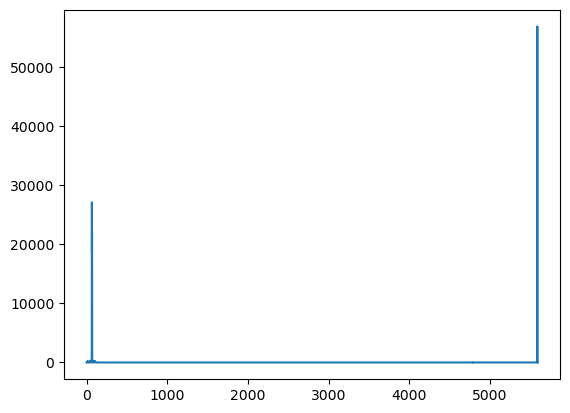

In [ ]:
import matplotlib.pyplot as plt

tmp = milp_info_compressed[0,milp_info_compressed[0,:]<100000]

plt.plot(tmp)
# plt.plot(stacked_states_train_tensor[0,0,0:4000])

In [1]:
from rail_rl_env import RailNet, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, gurobi_milp, num_station
import numpy as np

mipgap = 1e-3
early_term = 0
warm_start = 1
n_threads = 1
timelimit_gurobi = 10
log = 0

N = 40
Env = RailNet(N)

Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
print(Env.n_real.shape)

info = Env.step(0, d_pre, rho_whole, mipgap, log, timelimit_gurobi, early_term, warm_start, n_threads, opt='milp')[-1]
np.sum(Env.n_real[0,:,:]), np.sum(Env.n_real[1,:,:]), np.sum(Env.n_real[2,:,:])

(3, 260, 38)
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-25


(11198482.489914287, 32676441.33026258, 22145143.0605599)

In [2]:
info = Env.step(0, d_pre, rho_whole, mipgap, log, timelimit_gurobi, early_term, warm_start, n_threads, opt='milp')[-1]
np.sum(Env.n_real[0,:,:]), np.sum(Env.n_real[1,:,:]), np.sum(Env.n_real[2,:,:])

(11195634.1598, 32646341.133621663, 22135825.973631322)

In [1]:
from rail_data_preprocess_reduced import get_preprocessed_data_reduced

opt_data='milp_cl'
threshold_counts = 25
opt_state = 1
opt_label = 'classification'
N = 40

dict_data = get_preprocessed_data_reduced(opt_data, threshold_counts, N, opt_state, opt_label)

num_actions = 5
number of training points (before reduction): 140
number of validation points (before reduction): 18
number of test points (before reduction): 17
number of training points (after reduction): 140
number of validation points (after reduction): 18
number of test points (after reduction): 17
cntr_outlier_train: 136	 cntr_outlier_val: 18 cntr_outlier_test: 17
data-processing finished


In [2]:
import numpy as np
from rail_fun import norm_state

stacked_states = dict_data['stacked_states_train_tensor']
state = np.array(stacked_states)
state_min= np.min(state, axis=0)
state_max = np.max(state, axis=0)

In [5]:
np.max(state_max)

1.0

In [8]:
state_min_reduced.shape

(283,)

In [ ]:
tmp = np.random.rand(200,5)
tmp_min = np.min(tmp, axis=0)
tmp_max = np.max(tmp, axis=0)

array([0.00366122, 0.00479734, 0.00071147, 0.00274208, 0.00153451])

In [3]:
from rail_fun import downsample_average_state_rho

def get_State(Env):
    
    state_n = np.concatenate((Env.state_n[0,0:2*num_station[0]-1], Env.state_n[1,0:2*num_station[1]-1], Env.state_n[2,0:2*num_station[2]-1]))
    state_depot = Env.state_depot

    d = {}
    for i in range(3):
        d['state_l_' + str(i)] = np.concatenate((Env.state_l[0,i,0:2*num_station[0]-1], Env.state_l[1,i,0:2*num_station[1]-1], Env.state_l[2,i,0:2*num_station[2]-1]))
    state_l_0 = d['state_l_0']
    state_l_1 = d['state_l_1']
    state_l_2 = d['state_l_2']

    state_rho_down = downsample_average_state_rho(Env.state_rho, 9) # 4 samples of the passenger flow

    d = {}
    for i in range(4):
        d[str(i)] = np.concatenate((state_rho_down[0,i,0:2*num_station[0]-1], state_rho_down[1,i,0:2*num_station[1]-1], state_rho_down[2,i,0:2*num_station[2]-1]))
    state_rho_down = np.concatenate((d['0'], d['1'], d['2'], d['3']))

    state_rho_mean = np.mean(Env.state_rho, 1)
    state_rho_mean = np.concatenate((state_rho_mean[0,0:2*num_station[0]-1], state_rho_mean[1,0:2*num_station[1]-1], state_rho_mean[2,0:2*num_station[2]-1]))

    idx_cntr = np.array([Env.idx_cntr])
    
    return state_n, state_depot, idx_cntr, state_l_0, state_l_1, state_l_2, state_rho_down, state_rho_mean

state_n, state_depot, idx_cntr, state_l_0, state_l_1, state_l_2, state_rho_down, state_rho_mean = get_State(Env)

learning_data = {
    'state_n' : state_n,
    'state_depot' : state_depot,
    'idx_cntr' : idx_cntr,
    'state_l_0' : state_l_0,
    'state_l_1' : state_l_1,
    'state_l_2' : state_l_2,
    'state_rho_down' : state_rho_down,
    'state_rho_mean' : state_rho_mean
}

state_learning_core = np.concatenate((state_n, state_depot, idx_cntr))

state_learning_down = np.concatenate((state_n, state_depot, state_rho_down, state_l_0, idx_cntr))
state_learning_mean = np.concatenate((state_n, state_depot, state_rho_mean, state_l_0, idx_cntr))

state_learning_down_extended = np.concatenate((state_n, state_depot, state_rho_down, state_l_0, state_l_1, state_l_2, idx_cntr))
state_learning_mean_extended = np.concatenate((state_n, state_depot, state_rho_mean, state_l_0, state_l_1, state_l_2, idx_cntr))

state_learning_core.shape, state_learning_down.shape, state_learning_mean.shape, state_learning_down_extended.shape, state_learning_mean_extended.shape

((97,), (562,), (283,), (748,), (469,))

In [4]:
dict_state_list = {
    'state_n' : [],
    'state_depot' : [],
    'idx_cntr' : [],
    'state_l_0' : [],
    'state_l_1' : [],
    'state_l_2' : [],
    'state_rho_down' : [],
    'state_rho_mean' : []
}

def get_State(Env):
    
    state_n = np.concatenate((Env.state_n[0,0:2*num_station[0]-1], Env.state_n[1,0:2*num_station[1]-1], Env.state_n[2,0:2*num_station[2]-1]))
    state_depot = Env.state_depot

    d = {}
    for i in range(3):
        d['state_l_' + str(i)] = np.concatenate((Env.state_l[0,i,0:2*num_station[0]-1], Env.state_l[1,i,0:2*num_station[1]-1], Env.state_l[2,i,0:2*num_station[2]-1]))
    state_l_0 = d['state_l_0']
    state_l_1 = d['state_l_1']
    state_l_2 = d['state_l_2']

    state_rho_down = downsample_average_state_rho(Env.state_rho, 9) # 4 samples of the passenger flow

    d = {}
    for i in range(4):
        d[str(i)] = np.concatenate((state_rho_down[0,i,0:2*num_station[0]-1], state_rho_down[1,i,0:2*num_station[1]-1], state_rho_down[2,i,0:2*num_station[2]-1]))
    state_rho_down = np.concatenate((d['0'], d['1'], d['2'], d['3']))

    state_rho_mean = np.mean(Env.state_rho, 1)
    state_rho_mean = np.concatenate((state_rho_mean[0,0:2*num_station[0]-1], state_rho_mean[1,0:2*num_station[1]-1], state_rho_mean[2,0:2*num_station[2]-1]))

    idx_cntr = np.array([Env.idx_cntr])
    
    dict_state = {
    'state_n' : state_n,
    'state_depot' : state_depot,
    'idx_cntr' : idx_cntr,
    'state_l_0' : state_l_0,
    'state_l_1' : state_l_1,
    'state_l_2' : state_l_2,
    'state_rho_down' : state_rho_down,
    'state_rho_mean' : state_rho_mean
    }
    
    # return state_n, state_depot, idx_cntr, state_l_0, state_l_1, state_l_2, state_rho_down, state_rho_mean
    return dict_state

dict_state = get_State(Env)
for i in list(dict_state.keys()):
    dict_state_list[i].append(dict_state[i])

In [5]:
# Driver code
d1 = {'a': 10, 'b': 8}
d2 = {'d': 6, 'c': 4}

np.save('test.npy', (d1, d2), allow_pickle=True)

In [6]:
tmp = np.load('test.npy', allow_pickle=True)

In [9]:
type(tmp[0])

dict

In [204]:
from rail_training import Network

input_size = 291
hidden_size = 64
num_layers = 1
lr = 1e-4
n_actions = 250
batch_size = 1
dropout = 0

network = Network(input_size, hidden_size, num_layers, lr, n_actions, batch_size, dropout)

print(network.count_parameters())

68218


In [205]:
1600000/70000

22.857142857142858

In [166]:
def downsample_average(arr, n):
    end =  n * int(len(arr)/n)
    return np.mean(arr[:end].reshape(-1, n), 1)

a = np.array([0,1,5,7,2,1,3,4,20,15])
b = downsample_average(a,5)

a,b, np.mean(a), np.mean(b)

(array([ 0,  1,  5,  7,  2,  1,  3,  4, 20, 15]), array([3. , 8.6]), 5.8, 5.8)

In [16]:
from rail_rl_env import num_station

12+17+19

48

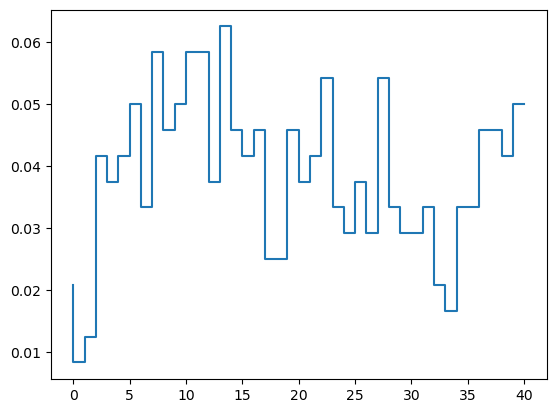

In [151]:
import matplotlib.pyplot as plt
import numpy as np

Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

y = Env.state_rho[0,:,0]
x = np.array(range(y.shape[0]))
plt.step(x, y)

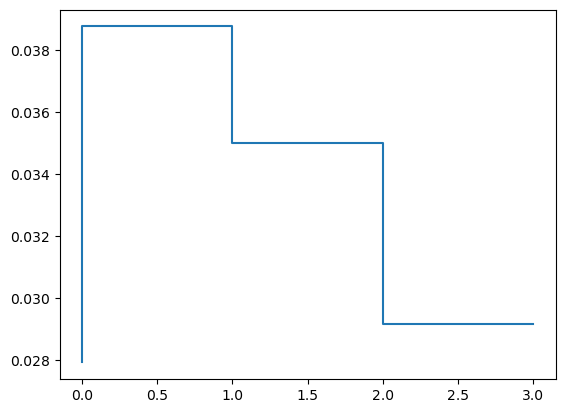

In [174]:
# y_red = Env.state_rho[0,::7,0]
y_red = downsample_average(y,10)
x_red = np.array(range(y_red.shape[0]))
plt.step(x_red, y_red)

In [128]:
y, y_red

(array([0.20416667, 0.15      , 0.14166667, 0.10833333, 0.15416667,
        0.21666667, 0.17083333, 0.10416667, 0.12083333, 0.1125    ,
        0.08333333, 0.1125    , 0.10416667, 0.14166667, 0.05416667,
        0.04166667, 0.05833333, 0.05      , 0.06666667, 0.075     ,
        0.04166667, 0.05833333, 0.05      , 0.01666667, 0.04166667,
        0.01666667, 0.04583333, 0.03333333, 0.02083333, 0.03333333,
        0.025     , 0.05416667, 0.0375    , 0.05833333, 0.05833333,
        0.03333333, 0.0375    , 0.04583333, 0.03333333, 0.05      ,
        0.03333333]),
 array([0.20416667, 0.21666667, 0.08333333, 0.04166667, 0.04166667,
        0.01666667, 0.025     , 0.03333333, 0.03333333]))

In [129]:
np.mean(y_red), np.mean(y)

(0.07731481481481482, 0.0755081300813008)

In [172]:
list_gap = []
downsample_factor = 8
for i in range(1000):
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    y = Env.state_rho[0,:,0]
    # y_red = y[::downsample_factor]
    y_red = downsample_average(y,10)
    mean_gap = np.abs( (np.mean(y)-np.mean(y_red))/(np.mean(y)) )
    list_gap.append(mean_gap)
    
print(np.mean(list_gap))

0.009277015193476089


In [173]:
y_red.shape

(4,)

In [4]:
Env.d_real.shape

(3, 260, 38)

In [22]:
d_stack = np.ones((100,5,30,3,260,38)) # method number, n_episode_steps, shape of d
a_stack = np.ones((100,5,30,3,260,38))
l_stack = np.ones((100,5,30,3,260,38))
n_stack = np.ones((100,5,30,3,260,38))
n_after_stack = np.zeros((100,5,30,3,260,38))
n_before_stack = np.zeros((100,5,30,3,260,38))
idx_cntr_stack = np.zeros((100,5,30,1))
step_cost_stack = np.zeros((100,5,30,1))
opt_gap_stack = np.zeros((100,5,30,1))

In [27]:
asd = [1,2,3,4,5]
asd[-1]

5

In [24]:
a = np.array([1,2,3,4,5])
a[1:2]

array([2])

In [7]:
Env.d_real.shape, Env.l_real.shape, Env.a_real.shape, Env.n_real.shape, Env.n_after_real.shape, Env.n_before_real.shape

((3, 260, 38),
 (3, 260, 38),
 (3, 260, 38),
 (3, 260, 38),
 (3, 260, 38),
 (3, 260, 38))

In [6]:
Env.state_d.shape, Env.state_a.shape, Env.state_n.shape, Env.state_n_after.shape, Env.state_n_before.shape

((3, 3, 38), (3, 43, 38), (3, 38), (3, 38), (3, 38))

In [10]:
Env.state_d[:,0,:]

array([[19200.        , 19082.38285714, 19082.79428571, 19027.92      ,
        19174.47428571, 19095.17142857, 19190.67428571, 19111.68      ,
        19035.82285714, 19051.2       , 18992.93142857, 19092.70285714,
        18964.13142857, 19063.90285714, 19005.63428571, 19021.01142857,
        19185.15428571, 19106.16      , 18961.66285714, 19122.36      ,
        19028.91428571, 18974.04      , 18974.45142857, 19096.83428571,
            0.        ,     0.        ,     0.        ,     0.        ,
            0.        ,     0.        ,     0.        ,     0.        ,
            0.        ,     0.        ,     0.        ,     0.        ,
            0.        ,     0.        ],
       [19200.        , 19166.00571429, 19048.02857143, 18962.09142857,
        19032.34285714, 19145.62285714, 19045.08      , 19051.40571429,
        19184.58857143, 19113.10285714, 19179.18857143, 19116.03428571,
        19041.63428571, 18972.30857143, 19089.39428571, 18967.76571429,
        19118.74285714,

In [1]:
import numpy as np
N=40
opt = 'minlp_cl'
minlp_info_compressed = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt, N, 0), allow_pickle=True).item()['milp_info_compressed']
for job_idx in range(1,99):
    tmp_vector = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt,N, job_idx), allow_pickle=True).item()['milp_info_compressed']
    minlp_info_compressed = np.concatenate((minlp_info_compressed, tmp_vector))
minlp_info_compressed = minlp_info_compressed[:150000, :]
np.save('data_optimal//data_%s_N%.2d_condensed.npy' %(opt,N), minlp_info_compressed, allow_pickle=True)

In [44]:
job_idx=99
tmp_vector = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt,N, job_idx), allow_pickle=True).item()['milp_info_compressed']
tmp_vector.shape

(1528, 5517)

In [42]:
from rail_rl_env import RailNet, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, action_dict

def compress_milp_info(state_n, state_rho, state_depot, state_l, delta_milp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status):
    
    milp_info_compressed = np.concatenate((state_n.flatten(), state_rho.flatten(), state_depot, state_l.flatten(), delta_milp.flatten(), mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status))
    
    return milp_info_compressed

Env = RailNet(N)
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

mipgap = 1e-3
early_term = 0
warm_start = 1
n_threads = 1
timelimit_gurobi = 10
log = 0

state_n = Env.state_n
state_rho = Env.state_rho
state_depot = Env.state_depot
state_l = Env.state_l

_, _, _, _, _, _, _, _, _, _, terminated, truncated, delta_milp, info = Env.step(0, d_pre, rho_whole, mipgap, log, timelimit_gurobi, early_term, warm_start, n_threads, 'minlp')
mdl = info['mdl']

mdl_Obj = np.array(mdl.ObjVal).reshape(1,)
mdl_mipgap = np.array(mdl.MIPGap).reshape(1,)
mdl_runtime = np.array(mdl.Runtime).reshape(1,)
mdl_status = np.array(mdl.Status).reshape(1,)

milp_info_compressed = []
milp_info_compressed.append(compress_milp_info(state_n, state_rho, state_depot, state_l, delta_milp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status))

In [43]:
milp_info_compressed[0].shape

(5593,)

In [35]:
5593-5517

76

In [17]:
from rail_rl_env import RailNet, gurobi_minlp, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, action_dict, mdl_feasible, gurobi_nlp_presolve
import numpy as np
from rail_fun import build_stacked_state, build_delta_vector
from rail_data_preprocess import get_preprocessed_data
from rail_training import Network, Network_CE, Network_mask1, Network_mask2
import torch
import time
# import matplotlib.pyplot as plt

N=40
Env = RailNet(N)
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

In [10]:
from rail_fun import build_list_action

# 1 train  -> 00
# 2 trains -> 10
# 3 trains -> 01
# 4 trains -> 11

N_control = N - 2
delta_heuristic = np.zeros((12,))
delta_heuristic[[2,6,10]] = 1     # 1st bit train composition
delta_heuristic[[3,7,11]] = 0     # 2nd bit train composition
delta_heuristic[[0,4,8]] = 1      # xi_1 indices
delta_heuristic[[1,5,9]] = 0      # xi_2 indices

stacked_delta_heuristic = []
for i in range(0,N_control):
    stacked_delta_heuristic.append(delta_heuristic)
stacked_delta_heuristic = np.array(stacked_delta_heuristic)

# list_action = build_list_action(stacked_delta_heuristic, N_control)

In [14]:
mipgap = 1e-3
log = 0
timelimit = 10
early_term = 0
warm_start = 0
n_threads = 4
i=0
cntr_infeasible=0

j=0

for i in range(1000):
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    while (Env.terminated or Env.truncated)==False:
        info_milp_lp = Env.step(stacked_delta_heuristic, d_pre, rho_whole, mipgap, log, timelimit, early_term, warm_start, n_threads, opt='lp')[-1]
        mdl = info_milp_lp['mdl']
        if mdl_feasible(mdl)==False:
            print('not feasible')
            cntr_infeasible +=1
        j=j+1
        if j%10==0:
            print('j = ',j)

j =  10
j =  20
j =  30
j =  40
j =  50
j =  60


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000292BF514A50>>
Traceback (most recent call last):
  File "c:\Users\franc\miniconda3\envs\RL_env\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

In [2]:
opt_data='minlp_ol'
threshold_counts = 25

output_get_preprocessed_data = get_preprocessed_data(opt_data, threshold_counts, N)

N = output_get_preprocessed_data[0]
N_control = output_get_preprocessed_data[1]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
list_masks=output_get_preprocessed_data[6]
stacked_states_val_tensor=output_get_preprocessed_data[8]
state_min_reduced=output_get_preprocessed_data[9]
state_max_reduced=output_get_preprocessed_data[10]
input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]

num_actions = total_action_set.shape[0]
seq_len=N_control

action_dict_reduced = {}
for i in total_action_set:
    action_dict_reduced[str(i)] = action_dict[str(i)]

num_actions = 378
number of training points (before reduction): 96000
number of validation points (before reduction): 24000
number of training points (after reduction): 92466
number of validation points (after reduction): 23152
cntr_outlier_train: 3534	 cntr_outlier_val: 848
data-processing finished


In [3]:
device = 'cpu'
batch_size = 1

def build_network(network_type, input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout, list_masks=list_masks, device=device):
    if network_type == 'Network':
        network = Network(input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout)
    elif network_type == 'Network_CE':
        network = Network_CE(input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout)
    elif network_type == 'Network_mask1':
        network = Network_mask1(input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout, list_masks, device)
    elif network_type == 'Network_mask2':
        network = Network_mask2(input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout, list_masks, device)
    else:
        raise KeyError('Network type has not been found.')
    
    return network

if opt_data=='minlp_ol':
    idx_best_networks = [9, 31, 7, 33, 43, 8, 24, 5, 42, 28, 32, 4, 29, 2, 26]
elif opt_data=='milp_ol':
    idx_best_networks = [31, 7, 10, 11, 26, 3, 2, 6, 33, 27, 43, 30, 8, 9, 42]
model_list = []
h0 = []
c0 = []
for i in idx_best_networks:
    network_info = np.load('training_data//' + opt_data + '_N%d_%.3d_' %(N,i) + 'info.npy', allow_pickle=True).item()
    network_type = network_info['network_type']
    input_size = network_info['input_size']
    hidden_size = network_info['hidden_size']
    num_layers = network_info['num_layers']
    lr = network_info['lr']
    dropout = network_info['dropout']
    
    network = build_network(network_type, input_size, hidden_size, num_layers, lr, num_actions, batch_size, dropout)
    network.load_state_dict(torch.load('training_data//' + opt_data + '_N%d_%.3d_' %(N,i) + 'weight'))
    
    h0.append(torch.zeros(num_layers, 1, hidden_size))
    c0.append(torch.zeros(num_layers, 1, hidden_size))
    
    model_list.append(network)
    
num_networks_minlp_ol = len(idx_best_networks)

In [19]:
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

log = 0
timelimit_gurobi = 30
mipgap = 1e-3
early_term = 0
warm_start = 1
n_threads = 4

a_values, d_values, r_values, l_values, y_values, delta_milp, n_values, n_after_values, mdl = gurobi_minlp(N,Env.d_pre_cut,Env.state_rho,Env.state_a,Env.state_d,Env.state_r,Env.state_l,Env.state_y,Env.state_n,Env.state_depot,mipgap,log,timelimit_gurobi,early_term,warm_start,n_threads)

state_learning = build_stacked_state(Env.state_n, Env.state_rho, Env.state_depot, Env.state_l, input_size, N_control, state_min_reduced, state_max_reduced)

opt_time = timelimit_gurobi
for i in range(len(model_list)):
    start_inf_time = time.time()
    # output_net = model_tscript_list[i](state_learning, h0[i], c0[i])*mask
    output_net = model_list[i](state_learning, h0[i], c0[i])
    action_idx = total_action_set[torch.max(output_net, dim=2)[1].squeeze().numpy()]
    delta_SL = build_delta_vector(action_idx, N_control, action_dict_reduced)
    inf_time = time.time()-start_inf_time

    opt_time = opt_time - inf_time

    a_values, d_values, r_values, l_values_learning, y_values, n_values, n_after_values,  mdl_learning = gurobi_nlp_presolve(N, Env.d_pre_cut, Env.state_rho, Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, delta_SL, mipgap, log, opt_time, early_term, warm_start, n_threads)
    
    opt_time = opt_time - mdl.Runtime
    
    number_model = i+1
    
    if mdl_feasible(mdl)==True:
        break

In [20]:
print(mdl.ObjVal)
print(mdl_learning.ObjVal)
print('opt gap is %.2f %%' %((mdl_learning.ObjVal-mdl.ObjVal)/mdl.ObjVal*100))

116069.8864902095
116069.88649022779
opt gap is 0.00 %


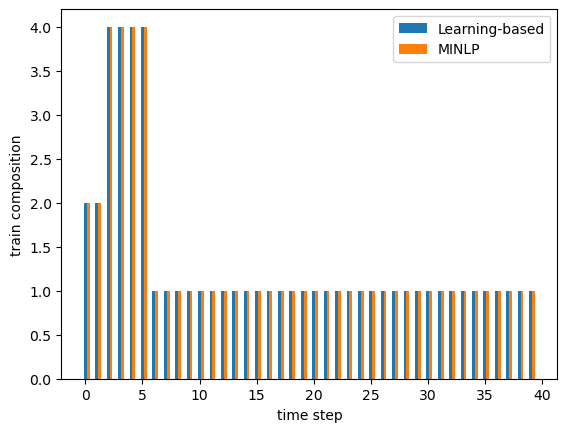

In [18]:
line = 0
station = 0

l_optimal = l_values[line]
l_learning = l_values_learning[line]

x = np.arange(l_optimal.shape[0])

plt.bar(x, l_learning[:,station], width=0.25, label='Learning-based')
plt.bar(x+0.25, l_optimal[:,station], width=0.25, label='MINLP')
# plt.bar(x+0.5, l_original[:,station], width=0.25, label='rule-based')
plt.legend()
plt.xlabel('time step')
plt.ylabel('train composition')
plt.show()

In [1]:
import numpy as np
import torch
from rail_data_preprocess import get_preprocessed_data

opt = 'milp_ol'
N = 40
threshold_counts = 25
output_get_preprocessed_data = get_preprocessed_data(opt, threshold_counts, N)

N = output_get_preprocessed_data[0]
N_control = output_get_preprocessed_data[1]
stacked_states_train=output_get_preprocessed_data[2]
stacked_states_val=output_get_preprocessed_data[3]
stacked_actions_reduced_train=output_get_preprocessed_data[4]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
list_masks=output_get_preprocessed_data[6]
stacked_states_train_tensor=output_get_preprocessed_data[7]
stacked_states_val_tensor=output_get_preprocessed_data[8]
state_min_reduced=output_get_preprocessed_data[9]
state_max_reduced=output_get_preprocessed_data[10]
input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]

num_actions = 237
number of training points (before reduction): 96000
number of validation points (before reduction): 24000
number of training points (after reduction): 94871
number of validation points (after reduction): 23704
cntr_outlier_train: 1129	 cntr_outlier_val: 296
data-processing finished


In [18]:
stacked_actions_reduced_train[[1,4,5,6]].shape

(4, 38)

In [ ]:
# network_info = np.load('training_data//' + opt + '_N%d_%.3d_' %(N,i) + 'info.npy', allow_pickle=True).item()
# network_info = np.load('training_data//minlp_ol_N40_009_info.npy', allow_pickle=True).item()

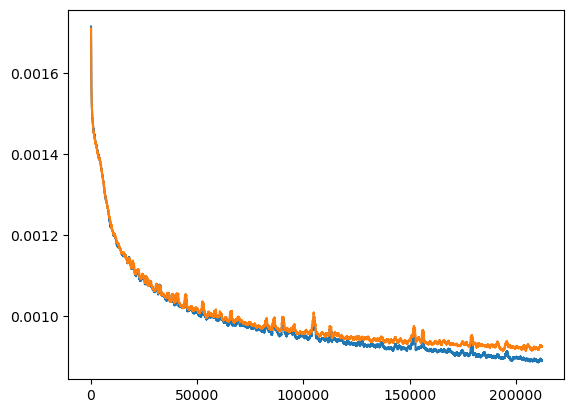

In [33]:
import matplotlib.pyplot as plt
import numpy as np

network_info = np.load('minlp_ol_N40_009_info.npy', allow_pickle=True).item()
loss_train = network_info['loss_train']
loss_val = network_info['loss_val']

def moving_average(a, n):
    #a: vector
    #n: moving average window size
    
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

plt.plot(moving_average(loss_train,1000))
plt.plot(moving_average(loss_val,1000))
plt.show()

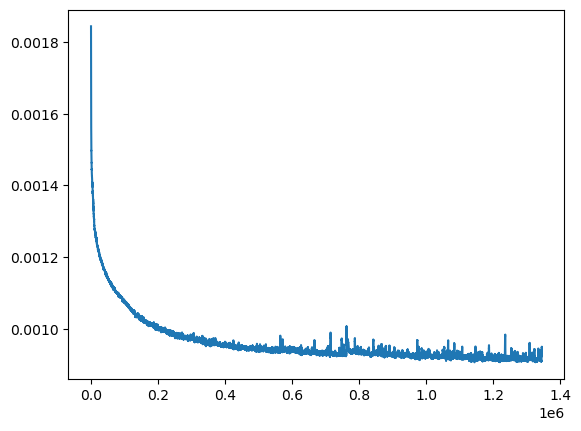

In [2]:
list_CE_weights = []
list_CE_masks = []
for j in range(N_control):
    actions_flattened = stacked_actions_reduced_train[:,j]
    action_idx, action_freq = np.unique(actions_flattened, return_counts=True)
    list_CE_masks.append(action_idx)
    tmp_vec = np.min(action_freq)/action_freq
    list_CE_weights.append(tmp_vec)
    
# list_masks = []

# for j in range(N_control):
#     mask = np.zeros(total_action_set.shape, dtype=np.int32)
#     for i in range(list_action_set[j].shape[0]):
#         mask[np.where(total_action_set==list_action_set[j][i])] = 1
#     list_masks.append(mask)

In [16]:
i = 32

# for i in range(len(list_masks)):
list_idx = []
for j in range(len(list_masks[i])):
    if list_masks[i][j] == 1:
        list_idx.append(j)
        
array_idx = np.array(list_idx)
# print(array_idx==list_CE_masks[i])
print(array_idx)
print(list_CE_masks[i])

[ 6  8  9 10 11 12 16 21 22 23 27 28 29 30 31 36 37 44 45 56 58 61]
[ 6  8  9 10 11 12 15 16 18 19 21 22 23 27 28 29 30 31 36 37 42 44 45 56
 58 61]


In [9]:
list_CE_masks

[array([ 23,  27,  31,  34,  37,  41,  45,  46,  47,  48,  49,  50,  51,
         52,  57,  72,  74,  91,  93, 109, 110, 111, 112, 113, 114]),
 array([  6,  23,  31,  37,  45,  46,  47,  48,  72,  91, 109, 110, 111]),
 array([  6,   7,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,  91,
         95, 109, 110, 111]),
 array([  6,   7,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,  91,
         95, 109, 110, 111]),
 array([  6,   7,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,  91,
         95, 109, 110, 111]),
 array([  6,   7,  17,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,
         91, 101, 109, 110, 111]),
 array([  6,   7,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,  78,
         80,  86,  88,  91, 100, 101, 109, 111]),
 array([  6,   7,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,  75,
         78,  80,  86,  88,  91, 100, 101, 109, 111]),
 array([  6,   7,  17,  23,  25,  31,  37,  39,  45,  46,  47,  48,  72,
         75,  78,  80,  86,  88,  91, 100

(94871,)


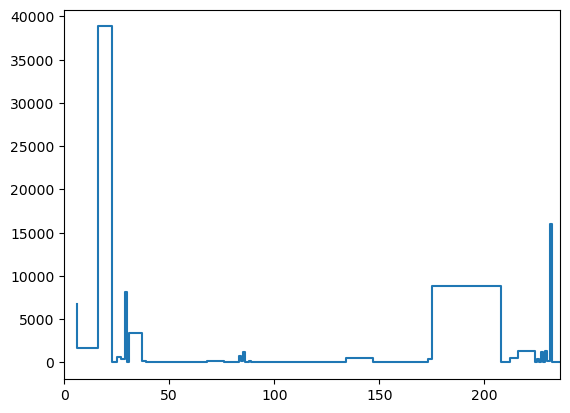

In [8]:
import matplotlib.pyplot as plt
# actions_flattened = stacked_actions_reduced_train.reshape(-1)
actions_flattened = stacked_actions_reduced_train[:,23]
print(actions_flattened.shape)
action_idx, action_freq = np.unique(actions_flattened, return_counts=True)
plt.step(action_idx, action_freq, '-')
plt.xlim(0, 236)
plt.show()
# action_idx, action_freq

In [72]:
a = np.array([1,2,3,4,5,6,7,8,9,100])
b = np.min(a)/a
b

array([1.        , 0.5       , 0.33333333, 0.25      , 0.2       ,
       0.16666667, 0.14285714, 0.125     , 0.11111111, 0.01      ])

In [77]:
torch.nn.CrossEntropyLoss()(torch.rand(10,), torch)

array([3.54358611e-04, 9.00900901e-03, 5.26315789e-02, 1.11482720e-03,
       2.29221107e-05, 1.42857143e-03, 2.12314225e-03, 2.02429150e-03,
       1.20977498e-04, 2.99132516e-04, 2.11416490e-03, 1.27762872e-04,
       1.00000000e+00, 2.61780105e-03, 5.98802395e-03, 3.84615385e-02,
       2.22222222e-02, 2.00000000e-01, 2.50000000e-01, 1.67504188e-03,
       2.05338809e-03, 1.00000000e+00, 2.41545894e-03, 7.69230769e-02,
       1.58177792e-04, 1.41442716e-03, 5.13083633e-04, 6.66666667e-02,
       4.92853622e-04, 3.99840064e-04, 1.42247511e-03, 3.33333333e-02,
       1.06112054e-04])

In [96]:
num_actions=237
list_CE_weights=[]
list_CE_masks = []
for i in range(N_control):
    actions_flattened = stacked_actions_reduced_train[:,i]
    action_idx, action_freq = np.unique(actions_flattened, return_counts=True)
    list_CE_masks.append(action_idx)
    # tmp_vec = np.zeros(num_actions)
    # tmp_vec[action_idx] = np.min(action_freq)/action_freq
    tmp_vec = np.min(action_freq)/action_freq
    list_CE_weights.append(tmp_vec)

# plt.step(action_idx, tmp, '-')
# plt.xlim(0, 236)
# plt.show()

In [9]:
import torch.nn.functional as F
import torch
import numpy as np

batch_size = 32
device = 'cpu'

mask = torch.tensor(np.array(list_masks, dtype=np.int32), device=device).unsqueeze(axis=0)
masks_tensor = mask
for i in range(1,batch_size):
    masks_tensor = torch.concatenate((masks_tensor, mask), dim=0)
    
mask = np.expand_dims(np.array(list_masks, dtype=np.int32), axis=0)
# mask = np.array(list_masks, dtype=np.int32)
mask_array = mask
for i in range(1, batch_size):    
    mask_array = np.concatenate((mask_array, mask))

print(mask_array.shape)
# masks_tensor = mask
# for i in range(1,batch_size):
#     masks_tensor = torch.concatenate((masks_tensor, mask), dim=0)

def my_MSE_loss(output, target):
    return F.mse_loss(output[mask_array], target[mask_array])

def my_CE_loss(output, target):
    return F.cross_entropy(output[mask_array], target[mask_array])

(32, 38, 237)


In [12]:
masks_tensor.bool()

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False,  True, False,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [False,  True,  True,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False,  True, False,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [False,  True,  True,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False,  True, False,  ..., False, False, False],
         [

In [17]:
output = torch.rand(32,38,237)
target = torch.rand(32,38,237)

In [21]:
output_mask = torch.masked_select(output, masks_tensor.bool())
target_mask = torch.masked_select(target, masks_tensor.bool())

output_mask.shape, target_mask.shape

(torch.Size([50944]), torch.Size([50944]))

In [23]:
F.cross_entropy(output,target), F.cross_entropy(output_mask, target_mask)

(tensor(69.9197), tensor(277768.1250))

In [24]:
F.mse_loss(output,target), F.mse_loss(output_mask, target_mask)

(tensor(0.1671), tensor(0.1669))

In [13]:
output = torch.rand(32,38,237)
target = torch.rand(32,38,237)

my_MSE_loss(output,target)

In [2]:
action_set, counts = np.unique(stacked_actions_reduced_train[:,0], return_counts=True)
action_set = action_set[np.where(counts>threshold_counts)]
list_action_set = [action_set.astype(np.int32)]
total_action_set = action_set.astype(np.int32)

for i in range(1,N_control):
    action_set, counts = np.unique(stacked_actions_reduced_train[:,i], return_counts=True)
    action_set = action_set[np.where(counts>threshold_counts)]
    total_action_set = np.union1d(total_action_set, action_set.astype(np.int32))
    list_action_set.append(action_set.astype(np.int32))

#creates the masking for each step of the control horizon
list_masks = []

for j in range(N_control):
    mask = np.zeros(total_action_set.shape, dtype=np.int32)
    for i in range(list_action_set[j].shape[0]):
        mask[np.where(total_action_set==list_action_set[j][i])] = 1
    list_masks.append(mask)
    
num_actions = total_action_set.shape[0]

In [1]:
import numpy as np
import torch
from rail_rl_env import RailNet
from rail_rl_env import gurobi_minlp, gurobi_milp, gurobi_nlp_presolve, gurobi_lp_presolve, mdl_feasible
# from rail_rl_env_0816 import RailNet
# from rail_rl_env_0816 import gurobi_minlp, gurobi_milp, gurobi_nlp_presolve, gurobi_lp_presolve, mdl_feasible
import time

from rail_rl_env import d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot

N=40
Env = RailNet(N)
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
n_threads = 1

In [2]:
from rail_data_preprocess import get_preprocessed_data

N = 40
opt = 'milp_ol'
threshold_counts = 25
output_get_preprocessed_data = get_preprocessed_data(opt, threshold_counts, N)

N = output_get_preprocessed_data[0]
N_control = output_get_preprocessed_data[1]
stacked_states_train=output_get_preprocessed_data[2]
stacked_states_val=output_get_preprocessed_data[3]
stacked_actions_reduced_train=output_get_preprocessed_data[4]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
list_masks=output_get_preprocessed_data[6]
stacked_states_train_tensor=output_get_preprocessed_data[7]
stacked_states_val_tensor=output_get_preprocessed_data[8]
state_min_reduced=output_get_preprocessed_data[9]
state_max_reduced=output_get_preprocessed_data[10]
input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]

num_actions = 237
number of training points (before reduction): 96000
number of validation points (before reduction): 24000
number of training points (after reduction): 94871
number of validation points (after reduction): 23704
cntr_outlier_train: 1129	 cntr_outlier_val: 296
data-processing finished


In [4]:
from rail_training import Network

batch_size=32
hidden_size=256
num_layers=1
lr=1e-4
n_actions = total_action_set.shape[0]

network = Network(input_size, hidden_size, num_layers, lr, n_actions, batch_size)

input = torch.randn(batch_size, N_control, input_size)
h0 = torch.zeros(num_layers, 32, hidden_size)
c0 = torch.zeros(num_layers, 32, hidden_size)

output = network(input, h0, c0)

# a = torch.rand(237,)

# a=a[np.nonzero(list_masks[0]==1)]
# a.shape


In [5]:
output.shape

torch.Size([32, 38, 237])

In [9]:
device='cpu'
mask = torch.tensor(np.array(list_masks, dtype=np.int32)).unsqueeze(axis=0).to(device)
masks_tensor = mask
for i in range(1,batch_size):
    masks_tensor = torch.concatenate((masks_tensor, mask), dim=0)
mask = masks_tensor

In [15]:
for i in range(len(list_masks)):
    print(np.sum(list_masks[i]==1))

23
13
16
17
14
14
16
20
18
17
20
31
75
108
120
119
115
123
129
101
66
50
39
33
26
26
27
27
24
38
27
18
22
25
15
8
6
6


In [8]:
Env.state_n.shape, Env.state_rho.shape, Env.state_depot.shape, Env.state_l.shape, Env.delta

((3, 38), (3, 41, 38), (3,), (3, 3, 38))

In [6]:
import numpy as np
N=40
minlp_info_compressed = np.load('data_milp//data_milp_N%.2d_%.2d.npy' %(N, 0), allow_pickle=True)
for job_idx in range(1,28):
    tmp_vector = np.load('data_milp//data_milp_N%.2d_%.2d.npy' %(N, job_idx), allow_pickle=True)
    minlp_info_compressed = np.concatenate((minlp_info_compressed, tmp_vector))
minlp_info_compressed = minlp_info_compressed[:120000, :]
np.save('data_milp//data_milp_ol_N%.2d_condensed.npy' %N, minlp_info_compressed, allow_pickle=True)

In [13]:
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

In [14]:
mipgap = 1e-3
log = 0
timelimit = 20
early_term = 0
warm_start = 0
n_threads = 1

a_values, d_values, r_values, l_values, y_values, delta_minlp, n_values, n_after_values, mdl = gurobi_minlp(N,Env.d_pre_cut,Env.state_rho,Env.state_a,Env.state_d,Env.state_r,Env.state_l,Env.state_y,Env.state_n,Env.state_depot,mipgap,log,timelimit,early_term, warm_start, n_threads)
print(mdl.MIPGap*100)

# a_values, d_values, r_values, l_values, y_values, delta_minlp, n_values, n_after_values, sign_o_values, mdl

7.13494383226792


In [15]:
# mdl.reset()
warm_start=1
# mdl_milp = gurobi_milp(N,Env.d_pre_cut,Env.state_rho,Env.state_a,Env.state_d,Env.state_r,Env.state_l,Env.state_y,Env.state_n,Env.state_depot,mipgap,log,timelimit_gurobi, n_threads)[-1]
a_values, d_values, r_values, l_values, y_values, delta, n_values, n_after_values, mdl = gurobi_minlp(N,Env.d_pre_cut,Env.state_rho,Env.state_a,Env.state_d,Env.state_r,Env.state_l,Env.state_y,Env.state_n,Env.state_depot,mipgap,log,timelimit,early_term , warm_start, n_threads)
print(mdl.MIPGap*100)

4.018198577433119


In [ ]:
mipgap =1e-3
log=0
timelimit=20
early_term=0
opt = 'minlp'
Env.step(0, d_pre, rho_whole, mipgap, log, timelimit, early_term, n_threads, opt)

In [2]:
from rail_training import Network, test_accuracy
from rail_data_preprocess import get_preprocessed_data
from rail_fun import build_stacked_state, build_delta_vector
from rail_rl_env import action_dict
import torch

opt_data='milp_ol'
opt_inference='nlp'
threshold_counts = 50
output_get_preprocessed_data = get_preprocessed_data(opt_data, threshold_counts)

input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]
N_control = output_get_preprocessed_data[1]
state_min_reduced=output_get_preprocessed_data[9]
state_max_reduced=output_get_preprocessed_data[10]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
stacked_states_val_tensor=output_get_preprocessed_data[8]

hidden_size=256
num_layers=1
lr=1e-4
batch_size=1
num_actions = total_action_set.shape[0]
seq_len=N_control
device = "cpu"

num_actions = 114
number of training points (before reduction): 126528
number of validation points (before reduction): 31632
number of training points (after reduction): 126102
number of validation points (after reduction): 31509
cntr_outlier_train: 426	 cntr_outlier_val: 123
data-processing finished


In [10]:
model1_str = 'milp_ol_hs256_N20_tc50_0808_1638_weight'
model2_str = 'milp_ol_hs256_N20_tc50_s04_0908_1310_weight'
model3_str = 'milp_ol_hs256_N20_tc50_s07_0908_1337_weight'
model4_str = 'milp_ol_hs256_N20_tc50_s11_0908_1435_weight'
model5_str = 'milp_ol_hs256_N20_tc50_s42_0908_1407_weight'
model_str_list = [model1_str, model2_str, model3_str, model4_str, model5_str]
model_list = []
for i in range(len(model_str_list)):
    model_list.append(Network(input_size, hidden_size, num_layers, lr, num_actions, batch_size))
    tmp_str = model_str_list[i]
    model_list[i].load_state_dict(torch.load('training_data//' + tmp_str, map_location=torch.device('cpu')))
# network = model_list[0]

# network = Network(input_size, hidden_size, num_layers, lr, num_actions, batch_size)
# model_str = 'milp_ol_hs256_N20_tc50_0808_1638_weight'
# network.load_state_dict(torch.load('training_data//' + model_str, map_location=torch.device('cpu')))

h0 = torch.zeros(num_layers, 1, hidden_size)
c0 = torch.zeros(num_layers, 1, hidden_size)

model_tscript_list = []
for i in range(len(model_list)):
    model_tscript_list.append(torch.jit.optimize_for_inference(torch.jit.script(model_list[i].eval())))

action_dict_reduced = {}
for i in total_action_set:
    action_dict_reduced[str(i)] = action_dict[str(i)]

In [14]:
mipgap = 1e-3
log = 0
timelimit = 10
early_term = 1
opt_inference = 'nlp'

for i in range(100):
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    state_learning = build_stacked_state(Env.state_n, Env.state_rho, Env.state_depot, Env.state_l, input_size, N_control, state_min_reduced, state_max_reduced)
    for i in range(len(model_list)):
        output_net = model_tscript_list[i](state_learning, h0, c0)
        action_idx = total_action_set[torch.max(output_net, dim=2)[1].squeeze().numpy()]
        delta_SL = build_delta_vector(action_idx, N_control, action_dict_reduced)
        if opt_inference=='nlp':
                # mdl = gurobi_nlp_presolve(Env.control_trains,Env.d_pre_cut,Env.state_rho, Env.state_a, Env.state_d,
                #                 Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, delta_SL, mipgap, log, timelimit, early_term, n_threads)[-1]
                a_values, d_values, r_values, l_values, y_values, n_values, n_after_values, sign_o_values, mdl = gurobi_nlp_presolve(N, Env.d_pre_cut, Env.state_rho, Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot,delta_SL, mipgap, log, timelimit, early_term, n_threads)
                
        elif opt_inference=='lp':
            mdl = gurobi_lp_presolve(Env.control_trains,Env.d_pre_cut,Env.state_rho, Env.state_a, Env.state_d,
                            Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, delta_SL, mipgap, log, timelimit, n_threads)[-1]
            
        if mdl_feasible(mdl)==True:
            print(mdl.status, i)
            break   

nlp_presolve: optimization did not converge to an optimal solution.
2 1
2 0
2 0
9 0
9 0
2 0
2 0
2 0
2 0
2 0
9 0
2 0
9 0
9 0
2 0
2 0
2 0
9 0
2 0
2 0
9 0
2 0
9 0
2 0
9 0
9 0
2 0
2 0
2 0
9 0
2 0
2 0
2 0
nlp_presolve: optimization did not converge to an optimal solution.
2 1
2 0
2 0
2 0
9 0
9 0
9 0
nlp_presolve: optimization did not converge to an optimal solution.
9 1
2 0
nlp_presolve: optimization did not converge to an optimal solution.
2 1
9 0
2 0
2 0
9 0
2 0
9 0
2 0
2 0
2 0
2 0
2 0
9 0
2 0
2 0
2 0
9 0
2 0
2 0
2 0
2 0
2 0
2 0
2 0
2 0
2 0
9 0
2 0
2 0
9 0
9 0
2 0
9 0
2 0
2 0
2 0
2 0
2 0
2 0
2 0
9 0
2 0
nlp_presolve: optimization did not converge to an optimal solution.
2 1
9 0
9 0
2 0
9 0
9 0
9 0
2 0
2 0
2 0
2 0
2 0
9 0
9 0
9 0
2 0


In [11]:
#tests inference time

N_iter = 1000

start_time=time.time()
list_time=[]
list_time2=[]

script_model = model_tscript_list[-1]

with torch.no_grad():
    for i in range(N_iter):        
        Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
        start_time=time.time()
        state_learning = build_stacked_state(Env.state_n, Env.state_rho, Env.state_depot, Env.state_l, input_size, N_control, state_min_reduced, state_max_reduced)
        # state_learning = torch.randn((1, N_control, input_size))    
        # output_net = script_model(state_learning, h0, c0)
        # with torch.no_grad():
        output_net = script_model(state_learning, h0, c0)
        action_idx = total_action_set[torch.max(output_net, dim=2)[1].squeeze().numpy()]
        delta_SL = build_delta_vector(action_idx, N_control, action_dict_reduced)
        total_time= time.time()-start_time
        list_time.append(total_time)
        
for i in range(N_iter):        
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    start_time=time.time()
    state_learning = build_stacked_state(Env.state_n, Env.state_rho, Env.state_depot, Env.state_l, input_size, N_control, state_min_reduced, state_max_reduced)
    # state_learning = torch.randn((1, N_control, input_size))    
    output_net = script_model(state_learning, h0, c0)
    # with torch.no_grad():
        # output_net = script_model(state_learning, h0, c0)
    action_idx = total_action_set[torch.max(output_net, dim=2)[1].squeeze().numpy()]
    delta_SL = build_delta_vector(action_idx, N_control, action_dict_reduced)
    total_time= time.time()-start_time
    list_time2.append(total_time)


print('total time: %.4f' %(np.sum(list_time)))
print('avg time: %.4f' %(np.mean(list_time)))

print('total time: %.4f' %(np.sum(list_time2)))
print('avg time: %.4f' %(np.mean(list_time2)))

total time: 1.4218
avg time: 0.0014
total time: 1.7861
avg time: 0.0018


In [2]:
# import numpy as np

# N=20
# shift=100
# n_workers=50
# minlp_info_compressed = np.load('data_minlp//data_minlp_N%.2d_%.2d.npy' %(N, shift), allow_pickle=True)
# for job_idx in range(shift+1,shift+n_workers):
#     tmp_vector = np.load('data_minlp//data_minlp_N%.2d_%.2d.npy' %(N, job_idx), allow_pickle=True)
#     minlp_info_compressed = np.concatenate((minlp_info_compressed, tmp_vector))
#     print(job_idx)
# np.save('data_minlp//data_minlp_ol_condensed2.npy', minlp_info_compressed, allow_pickle=True)

In [ ]:
job_idx = 44
minlp_info_compressed = np.load('data_minlp//data_minlp_N%.2d_%.2d.npy' %(N, job_idx), allow_pickle=True)
N_datapoints = minlp_info_compressed.shape[0]
# state_n, state_rho, state_depot, state_l, delta_minlp = decompress_minlp_info(minlp_info_compressed[j,:])

In [2]:
N_iter = 5

runtime_minlp = []
mipgap_minlp = []

for i in range(N_iter):
    start_time = time.time()
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    a_values, d_values, r_values, l_values, y_values, delta_minlp, n_values, n_after_values, sign_o_values, mdl = gurobi_minlp(N, Env.d_pre_cut, Env.state_rho,
                                Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, n_threads)
    end_time = time.time()
    runtime_minlp.append(end_time-start_time)
    mipgap_minlp.append(mdl.MIPGap)
    print(i, np.mean(runtime_minlp), np.mean(mipgap_minlp))

Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-25
Set parameter Threads to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.001
Set parameter MIPFocus to value 2
Set parameter NonConvex to value 2
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 1 threads

Optimize a model with 54357 rows, 40020 columns and 109532 nonzeros
Model fingerprint: 0x49b82d70
Model has 3456 quadratic objective terms
Model has 2211 quadratic constraints
Variable types: 27360 continuous, 12660 integer (5820 binary)
Coefficient statistics:
  Matrix range     [2e-02, 4e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+06]
  Objective range  [1e+00, 2e+02]
  QObjective range [2e-04, 2e-04]
  Bounds range     [1e+00, 4e+00]
  RHS rang

In [4]:
a_values, d_values, r_values, l_values, y_values, delta_minlp, n_values, n_after_values, sign_o_values, mdl = gurobi_minlp(N, Env.d_pre_cut, Env.state_rho,
                                Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, n_threads)

state_n = Env.state_n
state_rho = Env.state_rho
state_depot = Env.state_depot
state_l = Env.state_l
mdl_Obj = np.array(mdl.ObjVal).reshape(1,)
mdl_mipgap = np.array(mdl.MIPGap).reshape(1,)
mdl_runtime = np.array(mdl.Runtime).reshape(1,)
mdl_status = np.array(mdl.Status).reshape(1,)

def compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status):
    
    minlp_info_compressed = np.concatenate((state_n.flatten(), state_rho.flatten(), state_depot, state_l.flatten(), delta_minlp.flatten(), mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status))
    
    return minlp_info_compressed

Set parameter Threads to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.001
Set parameter MIPFocus to value 2
Set parameter NonConvex to value 2
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 1 threads

Optimize a model with 54357 rows, 40020 columns and 109532 nonzeros
Model fingerprint: 0xf8b1e5a9
Model has 3456 quadratic objective terms
Model has 2211 quadratic constraints
Variable types: 27360 continuous, 12660 integer (5820 binary)
Coefficient statistics:
  Matrix range     [1e-02, 4e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+06]
  Objective range  [2e+00, 2e+02]
  QObjective range [2e-04, 2e-04]
  Bounds range     [1e+00, 4e+00]
  RHS range        [1e+00, 2e+05]
  QRHS range       [2e+01, 1e+06]
Presolve removed 46631 rows and 3

In [16]:
tmp = compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status)
# tmp = tmp.reshape(1,3073)

In [15]:
asd = np.append(tmp,tmp, axis=0)
asd.shape

(2, 3073)

In [20]:
tmp_list = [tmp, tmp, tmp]
np.array(tmp_list).shape

(3, 3073)

In [4]:
'''
this file generates the data for the training of the supervised learning approach

it solves the MINLP and saves the states (parameters) and the solution in a .npy
'''

# import numpy as np
from rail_rl_env import RailNet, gurobi_minlp, qp_feasible
from rail_rl_env import d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot
from rail_rl_env import r_max, r_min, differ, Cmax, sigma, num_station, max_station, num_train, num_line, E_regular, olin, opla, otra, trans_rate
from rail_rl_env import epsilon, Mt, mt, t_roll, t_constant, h_min, tau_min, l_min, l_max, eta1, eta2

import time
import datetime

job_idx = 1
time_limit = 72 #hours

n_threads = 1
N_datapoints = 1

N = 20
N_control = N-1
Env = RailNet(N)

def compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status):
    
    minlp_info_compressed = np.concatenate((state_n.flatten(), state_rho.flatten(), state_depot, state_l.flatten(), delta_minlp.flatten(), mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status))
    
    return minlp_info_compressed

minlp_info_compressed = []
runtime_minlp = []
mipgap_minlp = []

cntr_feasible = 0

timeout = 600
# timeout = time_limit*60*60 - 0.2*60*60 # in hours
start_time = time.time()

i = 1
while time.time() < start_time + timeout:
# for i in range(N_datapoints):   
    
    Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)
    a_values, d_values, r_values, l_values, y_values, delta_minlp, n_values, n_after_values, sign_o_values, mdl = gurobi_minlp(N, Env.d_pre_cut, Env.state_rho,
                                Env.state_a, Env.state_d, Env.state_r, Env.state_l, Env.state_y, Env.state_n, Env.state_depot, n_threads)
    
    if qp_feasible(mdl)==True:
        state_n = Env.state_n
        state_rho = Env.state_rho
        state_depot = Env.state_depot
        state_l = Env.state_l
        mdl_Obj = np.array(mdl.ObjVal).reshape(1,)
        mdl_mipgap = np.array(mdl.MIPGap).reshape(1,)
        mdl_runtime = np.array(mdl.Runtime).reshape(1,)
        mdl_status = np.array(mdl.Status).reshape(1,)
        
        minlp_info_compressed.append(compress_minlp_info(state_n, state_rho, state_depot, state_l, delta_minlp, mdl_Obj, mdl_mipgap, mdl_runtime, mdl_status))
        cntr_feasible += 1
        
        elapsed_time = time.time()-start_time
        if i % 1 == 0:
            print('i=%d' %i, 'elapsed_time=%.2f' %elapsed_time, 'avg_solution_time=%.2f' %(elapsed_time/(i+1)), 'mipgap=%.2f' %mdl_mipgap.astype(np.float32), 'runtime=%.2f' %mdl_runtime.astype(np.float32), 'status=%.2f' %mdl_status.astype(np.float32) )    
    
    
    if i == 1:
        mdl.Params.LogToConsole = 1
        mdl.optimize()
        
    i+=1   
    
minlp_info_compressed = np.array(minlp_info_compressed)
    
x = datetime.datetime.now()
    
np.save('data_minlp//data_minlp_N%.2d_%.2d.npy' % (N, job_idx), minlp_info_compressed, allow_pickle=True)

print('cntr_feasible = %d' % cntr_feasible)
print('elapsed time = %.2f' % elapsed_time)
print('date and time : ' + '%.2d%.2d_%.2d%.2d%.2d' %(x.month, x.day, x.hour, x.minute, x.second))
print('completed')

# minlp_info_compressed = np.load('data_minlp//data_minlp_N%.2d.npy' %N, allow_pickle=True)
# N_datapoints = minlp_info_compressed.shape[0]
# state_n, state_rho, state_depot, state_l, delta_minlp = decompress_minlp_info(minlp_info_compressed[j,:])

i=0 elapsed_time=4.18 avg_solution_time=4.18 mipgap=0.00 runtime=2.77 status=2.00
Set parameter LogToConsole to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 1 threads

Optimize a model with 54357 rows, 40020 columns and 109532 nonzeros
Model fingerprint: 0x740d464c
Model has 3456 quadratic objective terms
Model has 2211 quadratic constraints
Variable types: 27360 continuous, 12660 integer (5820 binary)
Coefficient statistics:
  Matrix range     [1e-02, 4e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+06]
  Objective range  [2e+00, 2e+02]
  QObjective range [2e-04, 2e-04]
  Bounds range     [1e+00, 4e+00]
  RHS range        [1e+00, 1e+05]
  QRHS range       [2e+01, 1e+06]
Presolved: 14642 rows, 12255 columns, 46163 nonzeros
Presolved model has 3456 bilinear c

C:\Users\cfoliveiradasi\AppData\Local\Temp\ipykernel_18200\2696773535.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('i=%d' %i, 'elapsed_time=%.2f' %elapsed_time, 'avg_solution_time=%.2f' %(elapsed_time/(i+1)), 'mipgap=%.2f' %mdl_mipgap, 'runtime=%.2f' %mdl_runtime, 'status=%.2f' %mdl_status )


i=1 elapsed_time=35.02 avg_solution_time=17.51 mipgap=0.00 runtime=29.25 status=2.00
i=2 elapsed_time=336.58 avg_solution_time=112.19 mipgap=0.01 runtime=300.01 status=9.00
i=3 elapsed_time=638.35 avg_solution_time=159.59 mipgap=0.09 runtime=300.02 status=9.00
cntr_feasible = 4
elapsed time = 638.35
date and time : 0715_183106
completed
